In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset_path = '../data/e-commerce_customer_behavior.csv'
df = pd.read_csv(dataset_path)
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [5]:
# Check data types 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None


In [6]:
#Check missing values
print(df.isnull().sum())

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [7]:
# Handle missing values
# Drop rows with missing values
df = df.dropna()

In [8]:
# Encode categorical variables 
df = pd.get_dummies(df, drop_first=True)

In [9]:
df.head()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,Membership Type_Gold,Membership Type_Silver,Satisfaction Level_Satisfied,Satisfaction Level_Unsatisfied
0,101,29,1120.20,14,4.6,True,25,False,False,False,False,True,False,True,False,True,False
1,102,34,780.50,11,4.1,False,18,True,False,True,False,False,False,False,True,False,False
2,103,43,510.75,9,3.4,True,42,False,False,False,False,False,False,False,False,False,True
3,104,30,1480.30,19,4.7,False,12,True,False,False,False,False,True,True,False,True,False
4,105,27,720.40,13,4.0,True,55,True,False,False,True,False,False,False,True,False,True


In [10]:
# Exploratory Data Analysis (EDA)

# Summary statistics
print(df.describe())

       Customer ID         Age  Total Spend  Items Purchased  Average Rating  \
count   348.000000  348.000000   348.000000       348.000000      348.000000   
mean    275.887931   33.577586   847.793103        12.632184        4.023563   
std     101.304611    4.878024   361.692375         4.146079        0.579145   
min     101.000000   26.000000   410.800000         7.000000        3.000000   
25%     188.750000   30.000000   505.750000         9.000000        3.500000   
50%     276.500000   32.000000   780.200000        12.000000        4.100000   
75%     363.250000   37.000000  1160.600000        15.000000        4.500000   
max     450.000000   43.000000  1520.100000        21.000000        4.900000   

       Days Since Last Purchase  
count                348.000000  
mean                  26.614943  
std                   13.474750  
min                    9.000000  
25%                   15.000000  
50%                   23.000000  
75%                   38.000000  
max    

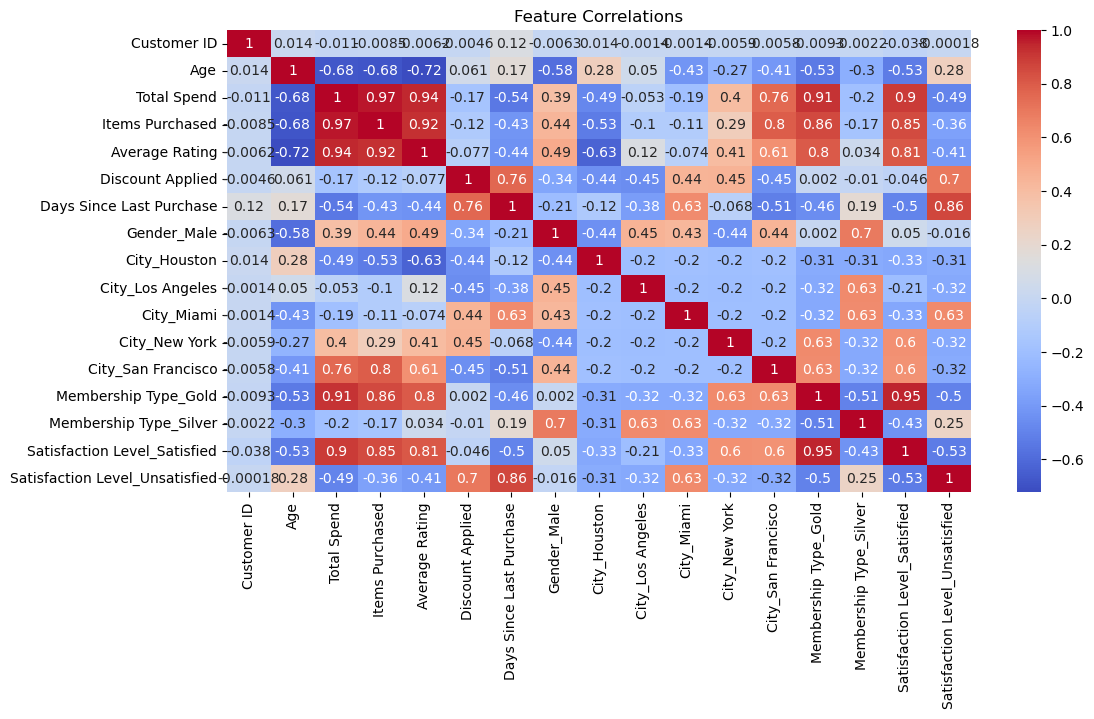

In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

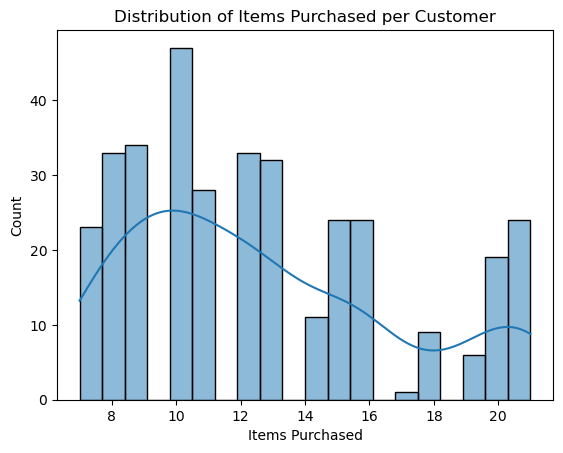

In [13]:
# Items Purchased Distribution
sns.histplot(df['Items Purchased'], bins=20, kde=True)
plt.title('Distribution of Items Purchased per Customer')
plt.show()

In [15]:
print(df.columns)

Index(['Customer ID', 'Age', 'Total Spend', 'Items Purchased',
       'Average Rating', 'Discount Applied', 'Days Since Last Purchase',
       'Gender_Male', 'City_Houston', 'City_Los Angeles', 'City_Miami',
       'City_New York', 'City_San Francisco', 'Membership Type_Gold',
       'Membership Type_Silver', 'Satisfaction Level_Satisfied',
       'Satisfaction Level_Unsatisfied'],
      dtype='object')


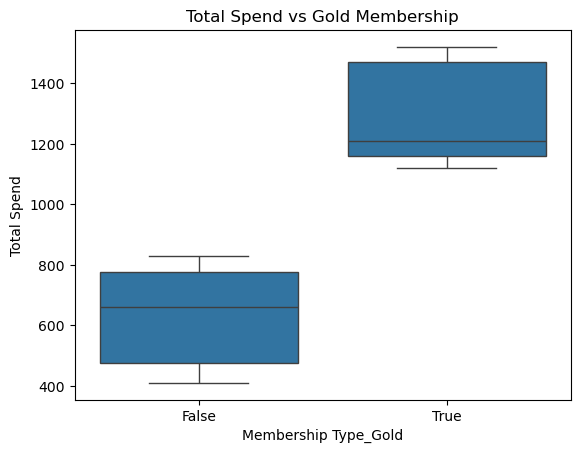

In [17]:
# Boxplot for Membership Type_Gold vs Total Spend
sns.boxplot(x='Membership Type_Gold', y='Total Spend', data=df)
plt.title('Total Spend vs Gold Membership')
plt.show()

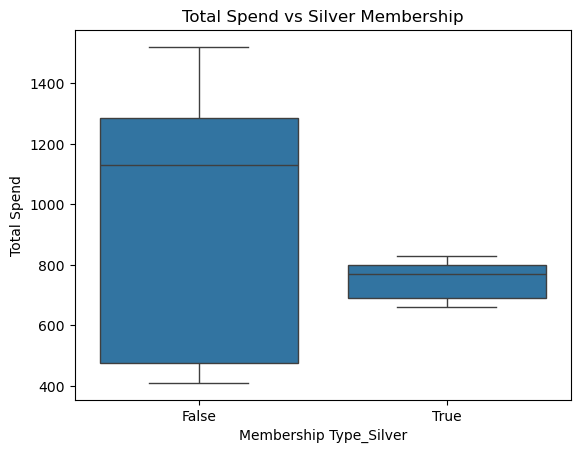

In [18]:
# Boxplot for Membership Type_Silver vs Total Spend
sns.boxplot(x='Membership Type_Silver', y='Total Spend', data=df)
plt.title('Total Spend vs Silver Membership')
plt.show()

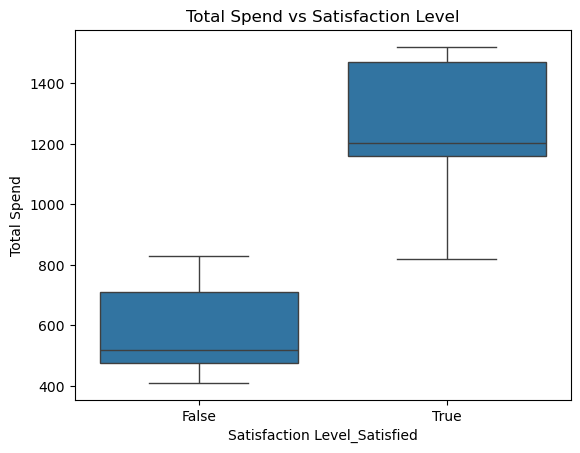

In [19]:
# Boxplot for Satisfaction Level_Satisfied vs Total Spend
sns.boxplot(x='Satisfaction Level_Satisfied', y='Total Spend', data=df)
plt.title('Total Spend vs Satisfaction Level')
plt.show()

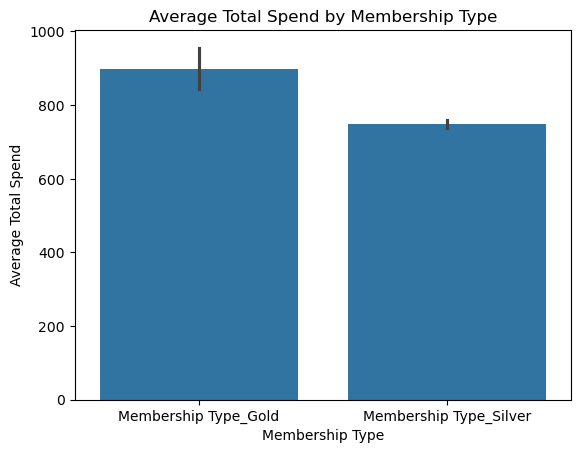

In [20]:
# Bar plot for Membership Type vs Average Total Spend
sns.barplot(x=df[['Membership Type_Gold', 'Membership Type_Silver']].idxmax(axis=1), y=df['Total Spend'])
plt.title('Average Total Spend by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Average Total Spend')
plt.show()

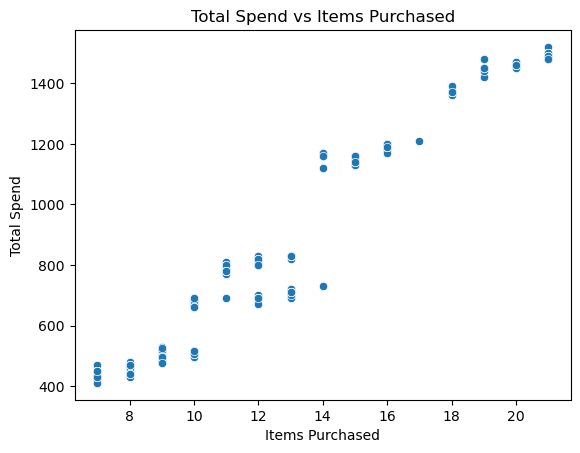

In [21]:
# Scatter plot for Total Spend vs Items Purchased
sns.scatterplot(x=df['Items Purchased'], y=df['Total Spend'])
plt.title('Total Spend vs Items Purchased')
plt.xlabel('Items Purchased')
plt.ylabel('Total Spend')
plt.show()

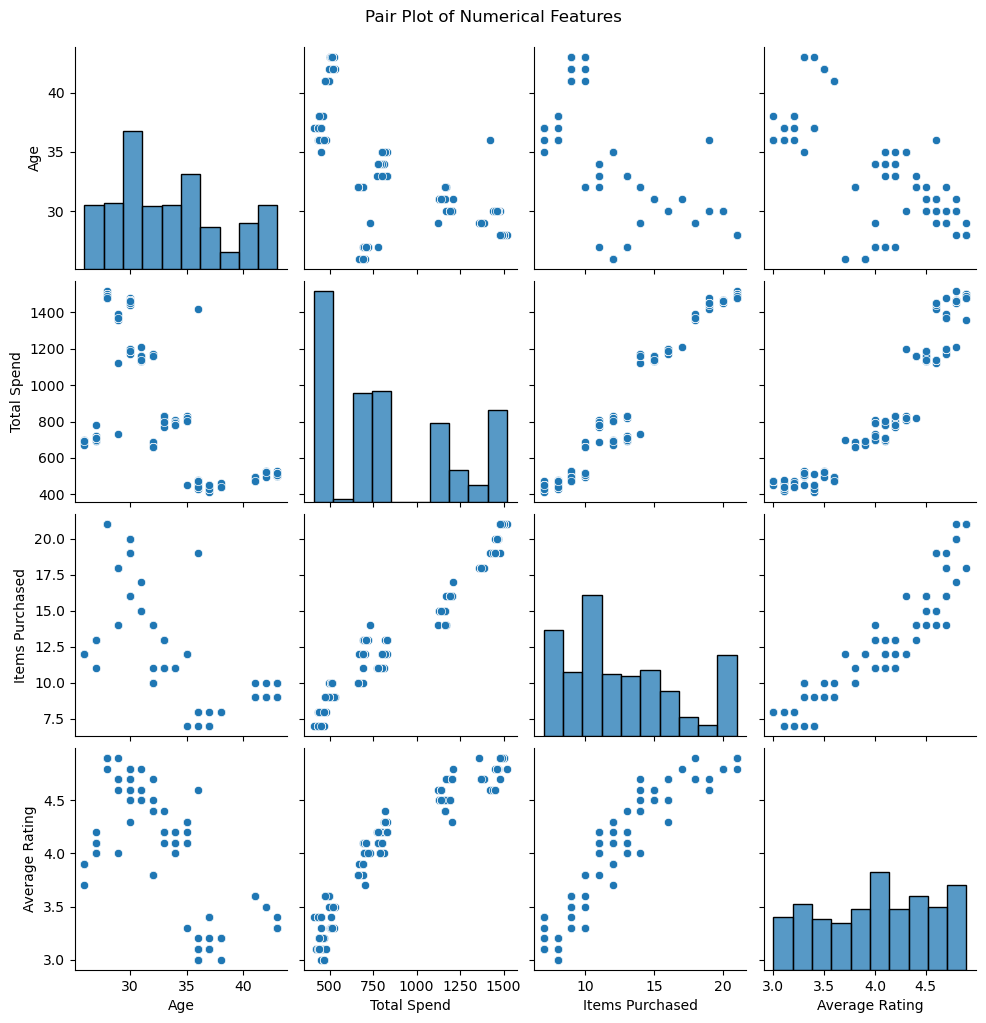

In [22]:
# Pair plot for numerical features
sns.pairplot(df[['Age', 'Total Spend', 'Items Purchased', 'Average Rating']])
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

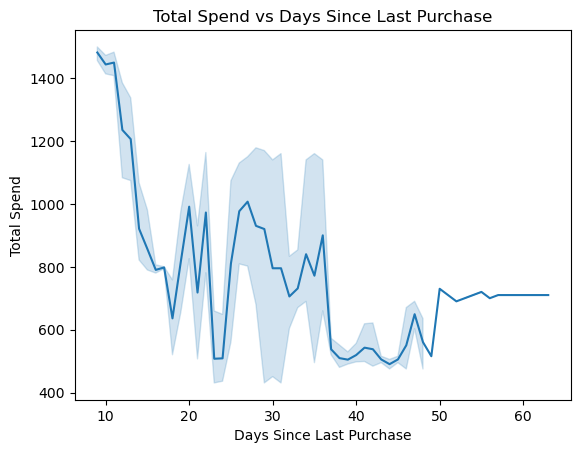

In [25]:
# Line plot for Total Spend vs Days Since Last Purchase
sns.lineplot(x=df['Days Since Last Purchase'], y=df['Total Spend'])
plt.title('Total Spend vs Days Since Last Purchase')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Spend')
plt.show()

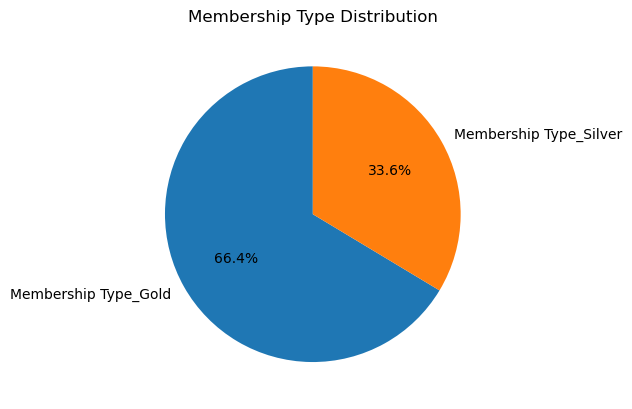

In [27]:
# Pie chart for Membership Type distribution
membership_counts = df[['Membership Type_Gold', 'Membership Type_Silver']].idxmax(axis=1).value_counts()
plt.pie(membership_counts, labels=membership_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Membership Type Distribution')
plt.show()

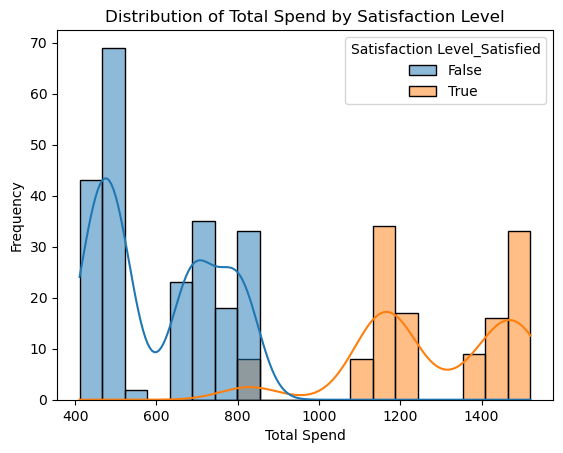

In [28]:
# Histogram of Total Spend for Satisfied vs Unsatisfied Customers
sns.histplot(data=df, x='Total Spend', hue='Satisfaction Level_Satisfied', kde=True, bins=20)
plt.title('Distribution of Total Spend by Satisfaction Level')
plt.xlabel('Total Spend')
plt.ylabel('Frequency')
plt.show()

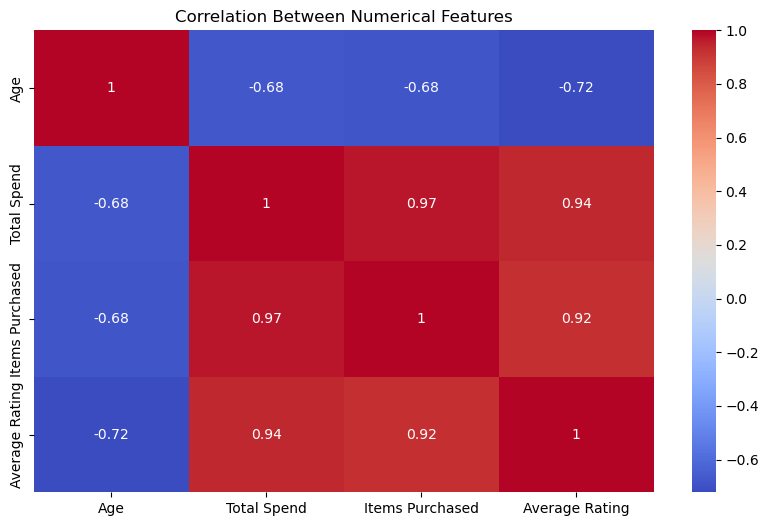

In [30]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Age', 'Total Spend', 'Items Purchased', 'Average Rating']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Features')
plt.show()

In [31]:
# Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target
X = df[['Age', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase']]  # Features
y = df['Total Spend']  # Target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R-squared:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R-squared: 0.9853119321779633
Mean Squared Error: 2104.240356783039
